In [1]:
# ---- importing functions ----
import sys
import numpy as np
import matplotlib.pyplot as plt

# importing slow dynamics pipeline
pipeline_dir = 'C:/Users/ys2605/Desktop/stuff/slow_dynamics_analysis'    # edit this  
sys.path.append(pipeline_dir + '/functions')
import sd_utils as sd

seed = 0           # integer for reproducible results, or None for random

In [12]:
# ---- Save figures as along the way ---- 
save_figs = True  # can turn on or off to save figures or not
fig_dir = 'C:/Users/ys2605/Desktop/stuff/papers/AC_paper_protocol/figures/python_corr'    # edit this

In [3]:
## ---- loading echo data ----
data_dir = 'F:/AC_data/caiman_data_echo/'    # edit this

# loading raw firing rates, trial types, and stimuli times from echo dataset
data_echo = sd.load_caim_data_mat(
    data_dir,                            # data directory
    ext_list=['mat'],                    # data extension
    tags=['cont', '_processed_data'],    # data tags
    num_files=None,                      # limit number of files to load
    deconvolution='smoothdfdt',               # deconvolution oasis or smoothdfdt
    smooth_std_duration=0.150)             # in sec

frame_rate = 1000/np.mean(sd.get_values(data_echo, 'volume_period')) # in Hz; edit this for external datasets
isi_list = np.array(sd.get_values(data_echo, 'isi'))


Loaded 24 datasets from 6 mice: [np.str_('M226'), np.str_('M4264'), np.str_('M4265'), np.str_('M4266'), np.str_('M4371'), np.str_('M4372')]


In [4]:
# ---- loading RNN testing with control datasets ----
data_dir_rnn = 'F:/RNN_stuff/RNN_data/test_data/'
fname_rnn = 'RNN_test_data_2024_5_24_9h_42m2'
data_rnn = sd.load_rnn_test(
    data_dir_rnn, 
    fname_rnn + '_cont_data.npy',
    fname_rnn + '_params.npy',
    max_net_load = 5,
    flatten_runs = True,
    max_trial_types = 10,
    max_trials = 2000,
    limit_network_types=['freq trained'], seed=seed)     # ob trained, freq trained, untrained

frame_rate_rnn = 1000/np.mean(sd.get_values(data_rnn, 'volume_period')) # in Hz; edit this for external datasets
training_type = np.array(sd.get_values(data_rnn, 'training'))

Loaded 5 RNN networks: {np.str_('freq trained'): 5}


In [5]:
## ---- calculate cell tuning and extract responsive cells ----

trial_frames, plot_t_tuning = sd.get_frames(
    trial_win=[-1, 2],         # sec relative to stim onset (pre, post)
    frame_rate=frame_rate)

# indicate a list of trial types to analyze. In this case the trial types are indexed from 1-10
trials_analyze = np.arange(1,11)

resp_cells_all = []
for n_fl in range(len(data_echo)):  
    # computing stimulus triggered average (neurons, frames, trials)
    stim_trig_resp = sd.get_stim_trig_resp(
        data_echo[n_fl]['firing_rates'],
        data_echo[n_fl]['stim_times'],
        trial_frames=trial_frames)

    print('computing stats dset %d/%d' % (n_fl+1, len(data_echo)))
    resp_cells = sd.compute_tuning(
        stim_trig_resp,
        data_echo[n_fl]['trial_types'],
        trials_analyze, plot_t_tuning,
        num_samp=2000,
        z_thresh = 3,
        sig_resp_win = [0, 1.2], seed=seed)
    
    resp_cells_all.append(resp_cells)

print('Done')

computing stats dset 1/24
computing stats dset 2/24
computing stats dset 3/24
computing stats dset 4/24
computing stats dset 5/24
computing stats dset 6/24
computing stats dset 7/24
computing stats dset 8/24
computing stats dset 9/24
computing stats dset 10/24
computing stats dset 11/24
computing stats dset 12/24
computing stats dset 13/24
computing stats dset 14/24
computing stats dset 15/24
computing stats dset 16/24
computing stats dset 17/24
computing stats dset 18/24
computing stats dset 19/24
computing stats dset 20/24
computing stats dset 21/24
computing stats dset 22/24
computing stats dset 23/24
computing stats dset 24/24
Done


In [6]:
## ---- correlation analysis CaIm echo data ----
trial_frames, plot_t = sd.get_frames(
    trial_win = [-0.05, .95],         # sec relative to stim onset (pre, post)
    frame_rate = frame_rate)

corr_vals_all = []
stim_trig_resp_all = []
for n_fl in range(len(data_echo)):
    stim_trig_resp = sd.get_stim_trig_resp(
        data_echo[n_fl]['firing_rates'],
        data_echo[n_fl]['stim_times'],
        trial_frames=trial_frames)

    stim_trig_resp_all.append(stim_trig_resp)
    
    corr_vals = sd.compute_correlation(
        stim_trig_resp,                     # stimulus triggered response matrix
        data_echo[n_fl]['trial_types'],     # vector of trial types
        trials_analyze,                     # trials types to analyze
        resp_cells = resp_cells_all[n_fl],  # logical vector of responsive cells
        metric='correlation',               # cosine, correlation
        min_resp_cells=5,                   # minimum number of responsive cells
        seed=seed)
    
    corr_vals_all.append(corr_vals)

corr_vals = np.vstack(corr_vals_all)
          

ISI 0.5 vs ISI 1 | mannwhitney (two-sided) | n1=23; n2=24 | stat=184 | p=0.0515 | n.s.
ISI 0.5 vs ISI 2 | mannwhitney (two-sided) | n1=23; n2=23 | stat=140 | p=0.006446 | **
ISI 0.5 vs ISI 4 | mannwhitney (two-sided) | n1=23; n2=23 | stat=168 | p=0.03494 | *


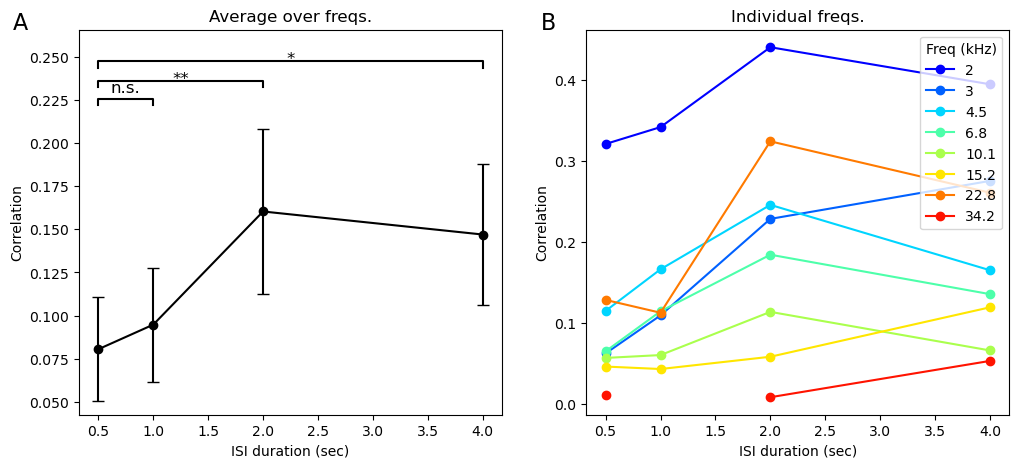

In [13]:
#  ---- plot correlation for trials 1-10 across ISI ----
import importlib
importlib.reload(sd)

fig, ax, groups = sd.plot_fig_isi_corr_trials(
    corr_vals,
    isi_list,
    colormap='jet',
    metric_tag = 'Correlation')

# statistical comparison: prints result + draws bracket on the panel (scale auto-detected)
# test: 'ttest' (Welch), 'mannwhitney', 'wilcoxon'/'ttest_rel' (paired); alternative: 'greater'/'less'/'two-sided'
sd.stat_compare(ax[0], groups, 'ISI 0.5', 'ISI 1', test='mannwhitney', alternative='two-sided')
sd.stat_compare(ax[0], groups, 'ISI 0.5', 'ISI 2', test='mannwhitney', alternative='two-sided')
sd.stat_compare(ax[0], groups, 'ISI 0.5', 'ISI 4', test='mannwhitney', alternative='two-sided')

# ---- save figure ----
if save_figs:
    sd.save_fig(fig, path=fig_dir, name_tag='Corr fig')

In [51]:
##  ---- example trial-to-trial cosine similarity ----
mouse_list, mouse_tag = sd.get_example_mouse(data_echo, example_mouse='M4372')
n_freq = 5

isi_uq = np.unique(isi_list)
SI_list = []
for n_isi in range(len(isi_uq)):
    mouse_idx2 = np.where((mouse_list == mouse_tag) 
                          & (isi_list == isi_uq[n_isi]))[0][0]
    trial_idx = data_echo[mouse_idx2]['trial_types'] == n_freq
    stim_trig_resp = stim_trig_resp_all[mouse_idx2][:,:,trial_idx]
    
    SI = sd.compute_correlation_mat(
        stim_trig_resp,
        subtract_mean=True, 
        add_noise_sigma=1e-5,
        metric='cosine', seed=seed)
    
    SI_list.append(SI)

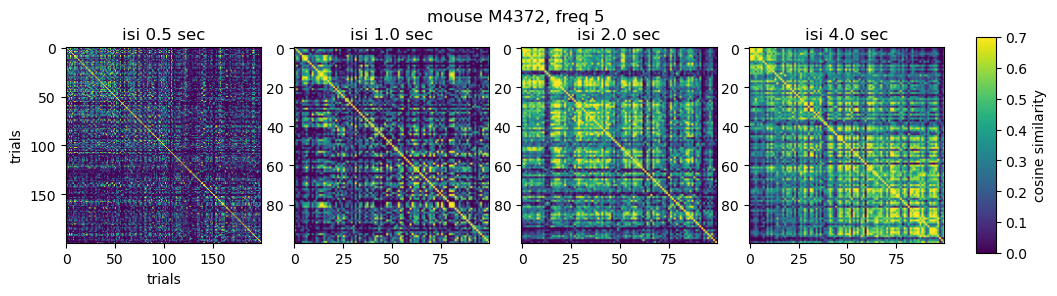

In [46]:
# ---- plot figure ----
fig = sd.plot_fig_SI_mat(
    SI_list,
    isi_uq,
    title_tag = 'mouse %s, freq %d' % (mouse_tag, n_freq))

# ---- save figure ----
if save_figs:    
    sd.save_fig(fig, path=fig_dir, name_tag='Corr SI mat')

Text(0, 0.5, 'cosine similarity')

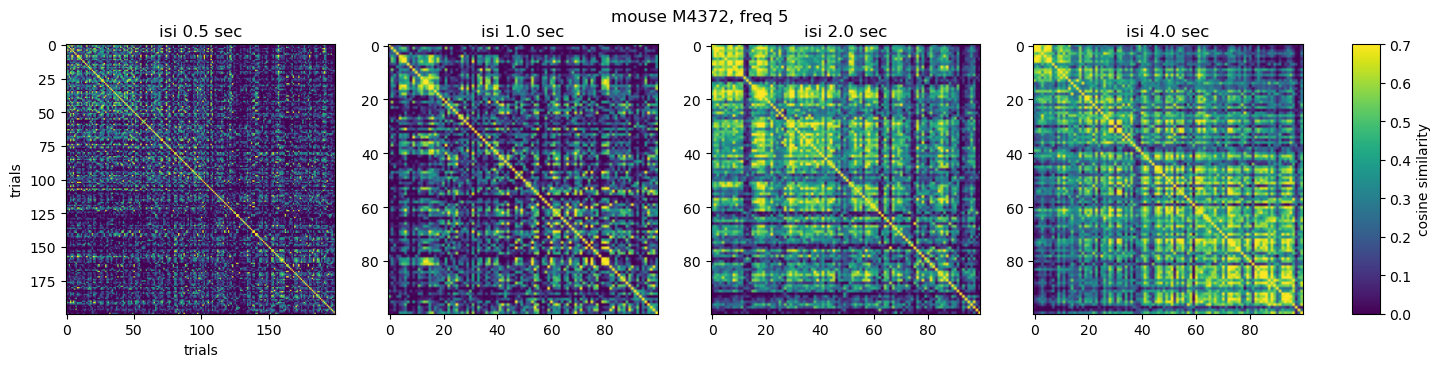

In [47]:
mouse_list, mouse_tag = sd.get_example_mouse(data_echo, example_mouse='M4372')
n_freq = 5

isi_uq = np.unique(isi_list)
fig, ax = plt.subplots(1,len(isi_uq)+1, gridspec_kw={'width_ratios': list(np.ones(len(isi_uq))*10) + [1]}, figsize=(17, 3.5))
for n_isi in range(len(isi_uq)):
    mouse_idx2 = np.where((mouse_list == mouse_tag) & (isi_list == isi_uq[n_isi]))[0][0]
    trial_idx = data_echo[mouse_idx2]['trial_types'] == n_freq
    
    stim_trig_resp = stim_trig_resp_all[mouse_idx2][:,:,trial_idx]
    
    SI = sd.compute_correlation_mat(stim_trig_resp, subtract_mean=True, add_noise_sigma=1e-5, metric='cosine', seed=seed)
    
    ax1 = ax.flatten()[n_isi]
    im = ax1.imshow(SI, vmin=0, vmax=.7)

    ax1.set_title('isi %s sec' % (isi_uq[n_isi]))

fig.suptitle('mouse %s, freq %d' % (mouse_tag, n_freq))
ax.flatten()[0].set_ylabel('trials')
ax.flatten()[0].set_xlabel('trials')
fig.colorbar(im, cax=ax.flatten()[-1])
ax.flatten()[-1].set_ylabel('cosine similarity')

In [18]:
## ---- correlation analysis RNN ----
trial_frames_rnn, plot_t_rnn = sd.get_frames(
    trial_win = [-0.05, .95],         # sec relative to stim onset (pre, post)
    frame_rate = frame_rate_rnn)

corr_vals_all_rnn = []
stim_trig_resp_all_rnn = []
for n_fl in range(len(data_rnn)):
    stim_trig_resp = sd.get_stim_trig_resp(
        data_rnn[n_fl]['firing_rates'],
        data_rnn[n_fl]['stim_times'],
        trial_frames=trial_frames_rnn)

    stim_trig_resp_all_rnn.append(stim_trig_resp)
    
    corr_vals = sd.compute_correlation(
        stim_trig_resp,                     # stimulus triggered response matrix
        data_rnn[n_fl]['trial_types'],     # vector of trial types
        np.unique(data_rnn[n_fl]['trial_types']),  # trials types to analyze (1-10)
        metric='correlation',               # cosine, correlation
        min_resp_cells=5, seed=seed)                   # minimum number of responsive cells
    
    corr_vals_all_rnn.append(corr_vals)

corr_vals_rnn = np.vstack(corr_vals_all_rnn)